# Neural Networks Assignment - Regression & Classification

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

## 1. Regression Dataset - House Price Prediction

In [45]:
np.random.seed(42)
N = 1200

area      = np.random.normal(1800, 500, N).clip(400, 5000)
bedrooms  = np.random.choice([1,2,3,4,5], N, p=[0.05,0.20,0.40,0.25,0.10])
bathrooms = np.random.choice([1,2,3,4], N, p=[0.20,0.45,0.25,0.10]).astype(float)
age       = np.random.exponential(15, N).clip(0, 80)
distance  = np.random.gamma(3, 4, N).clip(0.5, 60)
garage    = np.random.choice([0,1,2,3], N, p=[0.15,0.40,0.35,0.10]).astype(float)
neighbourhood = np.random.choice(
    ['Downtown','Suburbs','Rural','Waterfront','Industrial'],
    N, p=[0.20,0.35,0.20,0.15,0.10])

neigh_map  = {'Downtown':1.4,'Suburbs':1.0,'Rural':0.7,'Waterfront':1.7,'Industrial':0.6}
neigh_mult = np.array([neigh_map[n] for n in neighbourhood])

price = (80*area + 15000*bedrooms + 12000*bathrooms - 1500*age
         - 3000*distance + 8000*garage + np.random.normal(0,20000,N)) * neigh_mult
price = price.clip(50000, None)

# Outliers
oi = np.random.choice(N, 5, replace=False)
area[oi]  = np.random.uniform(8000, 12000, 5)
price[oi] = np.random.uniform(2_000_000, 5_000_000, 5)

# Missing values
bathrooms[np.random.choice(N, int(0.08*N), replace=False)] = np.nan
distance[np.random.choice(N,  int(0.08*N), replace=False)] = np.nan

df_reg = pd.DataFrame({'area_sqft':area,'bedrooms':bedrooms,'bathrooms':bathrooms,
                        'house_age':age,'distance_km':distance,'garage':garage,
                        'neighbourhood':neighbourhood,'price_usd':price})
print(df_reg.shape)
df_reg.head()

(1200, 8)


,area_sqft,bedrooms,bathrooms,house_age,distance_km,garage,neighbourhood,price_usd
0,2048.357077,1,NaN,2.669311,5.582979,1.0,Rural,123216.712269
1,1730.867849,3,2.0,3.994932,NaN,1.0,Suburbs,172275.567392
2,2123.844269,5,2.0,0.359900,11.951763,1.0,Downtown,304279.823501
3,2561.514928,3,3.0,27.022348,12.728446,2.0,Suburbs,219554.393124
4,1682.923313,4,NaN,55.148689,14.856230,1.0,Rural,97887.664363


## 2. Classification Dataset - Loan Default Prediction

In [46]:
np.random.seed(42)
N2 = 1500

income   = np.random.lognormal(10.5, 0.5, N2).clip(20000, 300000)
loan_amt = np.random.lognormal(9.5, 0.6, N2).clip(1000, 100000)
credit   = np.random.normal(660, 80, N2).clip(300, 850).astype(float)
emp_yrs  = np.random.exponential(5, N2).clip(0, 40).astype(float)
dti      = np.random.beta(2, 5, N2)
late_pay = np.random.poisson(1.0, N2).clip(0, 15)
purpose  = np.random.choice(['Home','Auto','Education','Medical','Personal'],
                             N2, p=[0.30,0.20,0.15,0.15,0.20])

# Risk-based assignment targeting ~30% default rate
default = np.zeros(N2, dtype=int)
for i in range(N2):
    c = credit[i] if not np.isnan(credit[i]) else 660
    d, l = dti[i], late_pay[i]
    if c < 580 or d > 0.50 or l >= 4:
        p = 0.85
    elif c < 650 or d > 0.35 or l >= 2:
        p = 0.35
    else:
        p = 0.05
    default[i] = int(np.random.random() < p)

# Outliers and missing values
income[np.random.choice(N2, 10, replace=False)] = np.random.uniform(500000, 1500000, 10)
credit[np.random.choice(N2, int(0.07*N2), replace=False)]  = np.nan
emp_yrs[np.random.choice(N2, int(0.06*N2), replace=False)] = np.nan

df_clf = pd.DataFrame({'annual_income':income,'loan_amount':loan_amt,'credit_score':credit,
                        'employment_years':emp_yrs,'debt_to_income':dti,
                        'late_payments':late_pay,'loan_purpose':purpose,'defaulted':default})

counts = df_clf['defaulted'].value_counts()
print('Class distribution:')
print(counts)
print('Default rate:', round(default.mean()*100, 1), '%')

Class distribution:
defaulted
0    907
1    593
Name: count, dtype: int64
Default rate: 39.5 %


## 3. EDA

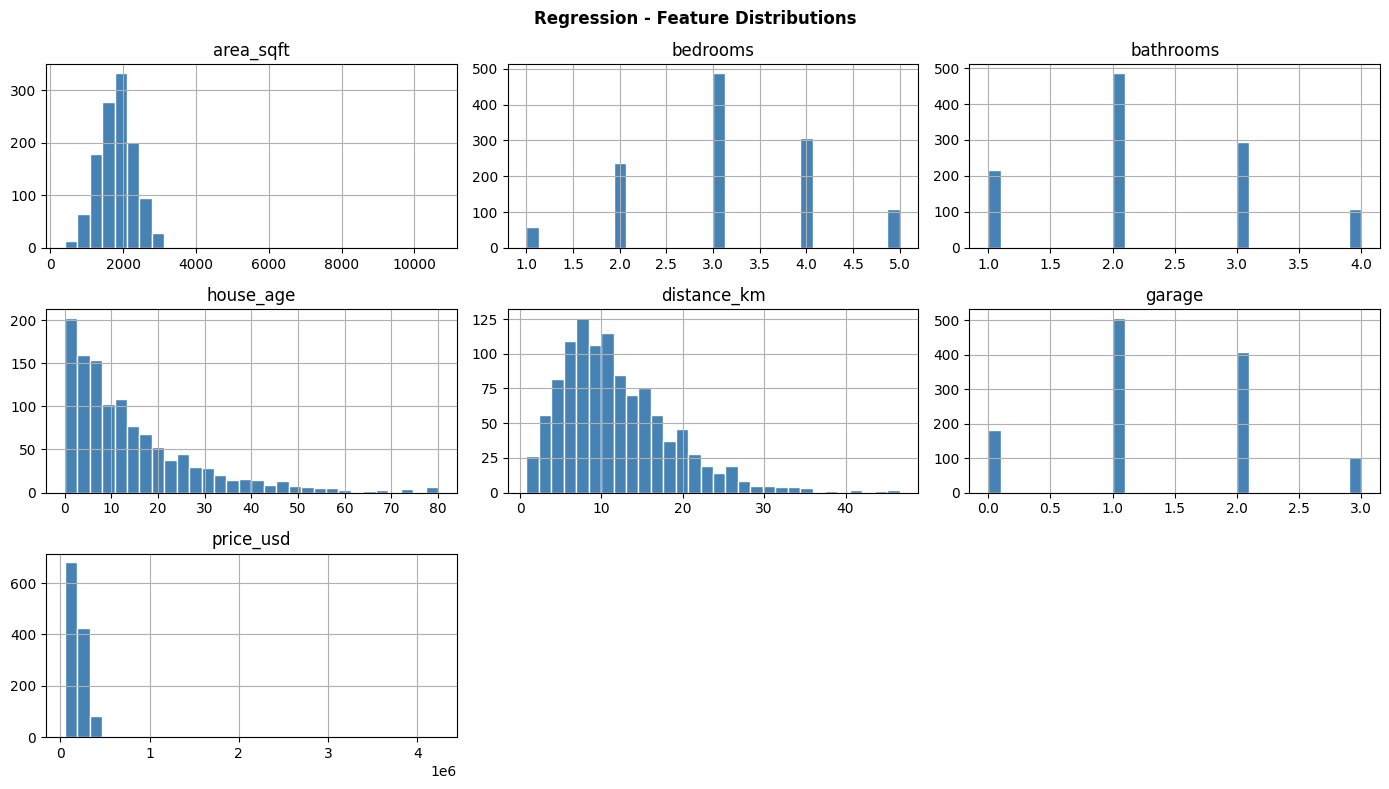

In [47]:
df_reg.select_dtypes(include='number').hist(bins=30, figsize=(14,8), color='steelblue', edgecolor='white')
plt.suptitle('Regression - Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
print('Regression missing values:')
print(df_reg.isnull().sum()[df_reg.isnull().sum()>0])
print()
print('Classification missing values:')
print(df_clf.isnull().sum()[df_clf.isnull().sum()>0])

Regression missing values:
bathrooms      96
distance_km    96
dtype: int64

Classification missing values:
credit_score        105
employment_years     90
dtype: int64


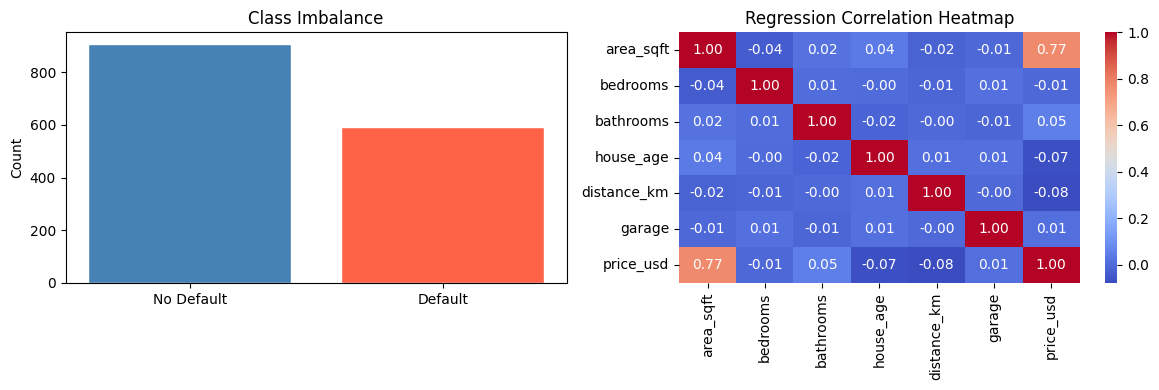

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clf['defaulted'].value_counts()
axes[0].bar(['No Default','Default'], counts.values, color=['steelblue','tomato'], edgecolor='white')
axes[0].set_title('Class Imbalance'); axes[0].set_ylabel('Count')

sns.heatmap(df_reg.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Regression Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [50]:
# Regression
df_r = pd.get_dummies(df_reg, columns=['neighbourhood'], drop_first=False)
X_r  = df_r.drop('price_usd', axis=1).values
y_r  = df_r['price_usd'].values

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_r, y_r, test_size=0.30, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

imp_r = SimpleImputer(strategy='median')
X_tr  = imp_r.fit_transform(X_tr)
X_val = imp_r.transform(X_val)
X_te  = imp_r.transform(X_te)

sc_r  = StandardScaler()
X_tr  = sc_r.fit_transform(X_tr)
X_val = sc_r.transform(X_val)
X_te  = sc_r.transform(X_te)

y_mean, y_std = y_tr.mean(), y_tr.std()
y_tr_s  = (y_tr  - y_mean) / y_std
y_val_s = (y_val - y_mean) / y_std
y_te_s  = (y_te  - y_mean) / y_std

print('Regression splits:', X_tr.shape, X_val.shape, X_te.shape)

Regression splits: (840, 11) (180, 11) (180, 11)


In [51]:
# Classification
df_c = pd.get_dummies(df_clf, columns=['loan_purpose'], drop_first=False)
X_c  = df_c.drop('defaulted', axis=1).values
y_c  = df_c['defaulted'].values

X_tr_c, X_tmp_c, y_tr_c, y_tmp_c = train_test_split(X_c, y_c, test_size=0.30, random_state=42, stratify=y_c)
X_val_c, X_te_c, y_val_c, y_te_c = train_test_split(X_tmp_c, y_tmp_c, test_size=0.50, random_state=42)

imp_c = SimpleImputer(strategy='median')
X_tr_c  = imp_c.fit_transform(X_tr_c)
X_val_c = imp_c.transform(X_val_c)
X_te_c  = imp_c.transform(X_te_c)

sc_c  = StandardScaler()
X_tr_c  = sc_c.fit_transform(X_tr_c)
X_val_c = sc_c.transform(X_val_c)
X_te_c  = sc_c.transform(X_te_c)

n_neg = (y_tr_c == 0).sum()
n_pos = (y_tr_c == 1).sum()
class_weight = {0: 1.0, 1: round(n_neg / n_pos, 2)}
print('Classification splits:', X_tr_c.shape, X_val_c.shape, X_te_c.shape)
print('Class weights:', class_weight)

Classification splits: (1050, 11) (225, 11) (225, 11)
Class weights: {0: 1.0, 1: np.float64(1.53)}


## 5. Neural Network - Regression

In [52]:
reg_model = keras.Sequential([
    layers.Input(shape=(X_tr.shape[1],)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.30),
    layers.Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.20),
    layers.Dense(32,  activation='relu'),
    layers.Dense(1,   activation='linear')
])
reg_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])
reg_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
es_reg = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

history_reg = reg_model.fit(
    X_tr, y_tr_s,
    validation_data=(X_val, y_val_s),
    epochs=200, batch_size=32,
    callbacks=[es_reg], verbose=0
)
print('Stopped at epoch:', len(history_reg.history['loss']))

Epoch 76: early stopping
Restoring model weights from the end of the best epoch: 56.
Stopped at epoch: 76


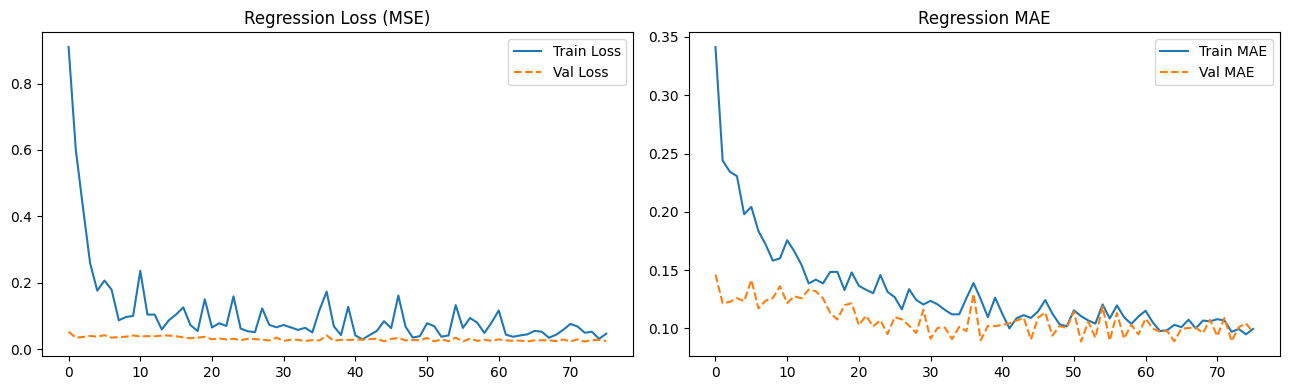

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_reg.history['loss'],     label='Train Loss')
axes[0].plot(history_reg.history['val_loss'], label='Val Loss',  linestyle='--')
axes[0].set_title('Regression Loss (MSE)'); axes[0].legend()
axes[1].plot(history_reg.history['mae'],      label='Train MAE')
axes[1].plot(history_reg.history['val_mae'],  label='Val MAE',   linestyle='--')
axes[1].set_title('Regression MAE'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Neural Network - Classification

In [55]:
clf_model = keras.Sequential([
    layers.Input(shape=(X_tr_c.shape[1],)),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.35),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(1,  activation='sigmoid')
])
clf_model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
clf_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 128 (512.00 B)

In [56]:
es_clf = EarlyStopping(monitor='val_auc', patience=25, restore_best_weights=True, mode='max', verbose=1)

history_clf = clf_model.fit(
    X_tr_c, y_tr_c,
    validation_data=(X_val_c, y_val_c),
    epochs=200, batch_size=32,
    class_weight=class_weight,
    callbacks=[es_clf], verbose=0
)
print('Stopped at epoch:', len(history_clf.history['loss']))

Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 14.
Stopped at epoch: 39


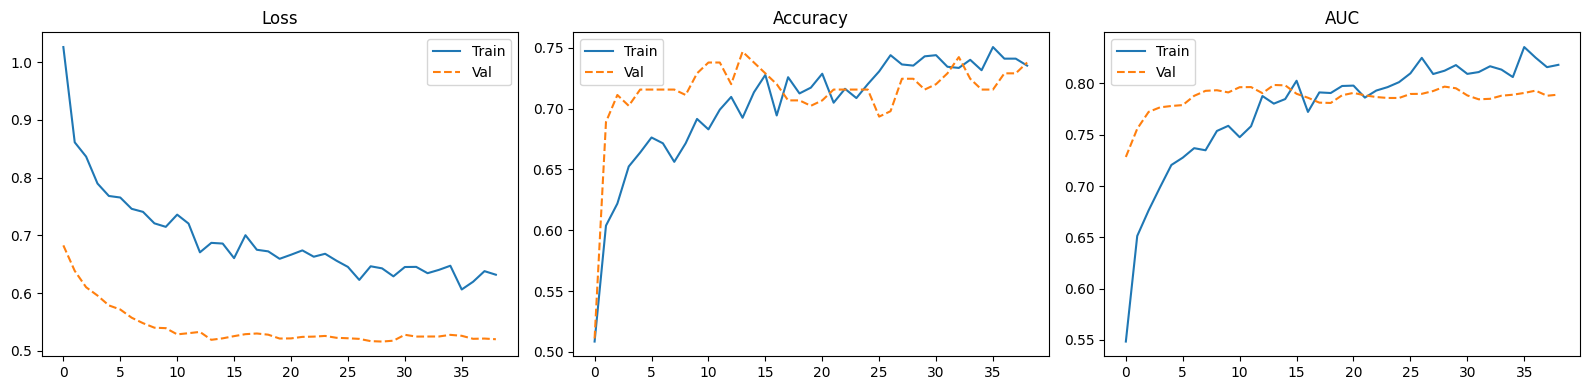

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_clf.history['loss'],      label='Train'); axes[0].plot(history_clf.history['val_loss'],     label='Val', linestyle='--'); axes[0].set_title('Loss');     axes[0].legend()
axes[1].plot(history_clf.history['accuracy'],  label='Train'); axes[1].plot(history_clf.history['val_accuracy'],label='Val', linestyle='--'); axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].plot(history_clf.history['auc'],       label='Train'); axes[2].plot(history_clf.history['val_auc'],     label='Val', linestyle='--'); axes[2].set_title('AUC');      axes[2].legend()
plt.tight_layout(); plt.show()

## 7. Evaluation

In [58]:
y_pred_s = reg_model.predict(X_te, verbose=0).flatten()
y_pred   = y_pred_s * y_std + y_mean

print('Regression Metrics')
print('MAE: ', round(mean_absolute_error(y_te, y_pred), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_te, y_pred)), 2))
print('R2:  ', round(r2_score(y_te, y_pred), 4))

Regression Metrics
MAE:  23848.33
RMSE: 30236.06
R2:   0.8604


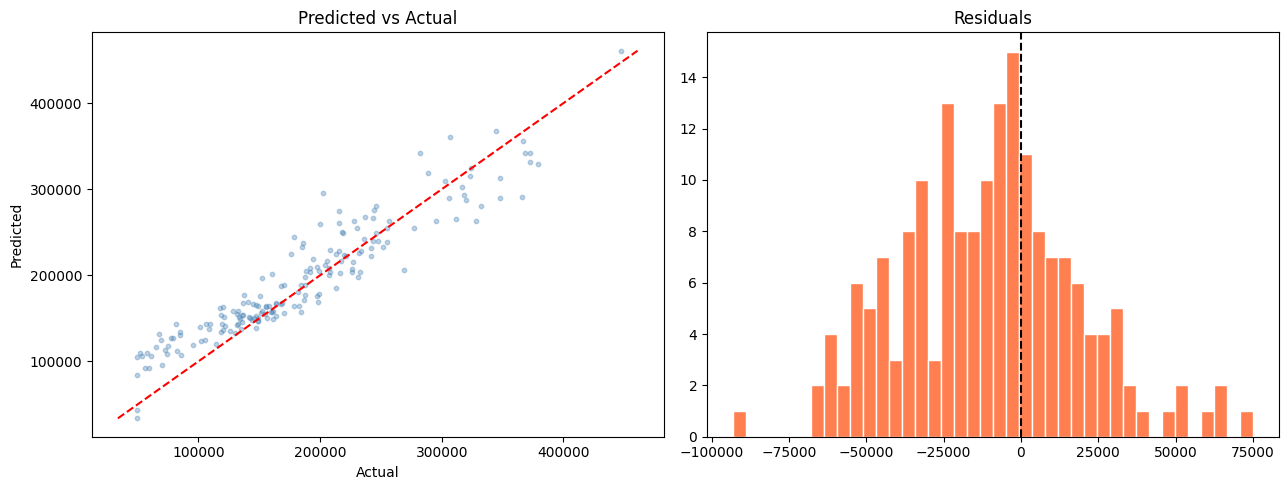

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_te, y_pred, alpha=0.35, s=10, color='steelblue')
mn, mx = min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())
axes[0].plot([mn,mx],[mn,mx],'r--')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual')

axes[1].hist(y_te - y_pred, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residuals')
plt.tight_layout(); plt.show()

In [66]:
y_prob   = clf_model.predict(X_te_c, verbose=0).flatten()

# Find optimal threshold by best macro F1
from sklearn.metrics import f1_score
thresholds = np.arange(0.20, 0.70, 0.01)
best_thresh, best_f1 = 0.5, 0.0
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    f1 = f1_score(y_te_c, preds, average='macro')
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

y_pred_c = (y_prob >= best_thresh).astype(int)
print('Optimal threshold:', round(best_thresh, 2))
print()
print('Classification Report')
print(classification_report(y_te_c, y_pred_c, target_names=['No Default','Default']))
auc_val = roc_auc_score(y_te_c, y_prob)
print('ROC-AUC:', round(auc_val, 4))

Optimal threshold: 0.5

Classification Report
              precision    recall  f1-score   support

  No Default       0.72      0.78      0.75       126
     Default       0.69      0.62      0.65        99

    accuracy                           0.71       225
   macro avg       0.70      0.70      0.70       225
weighted avg       0.71      0.71      0.70       225

ROC-AUC: 0.7603


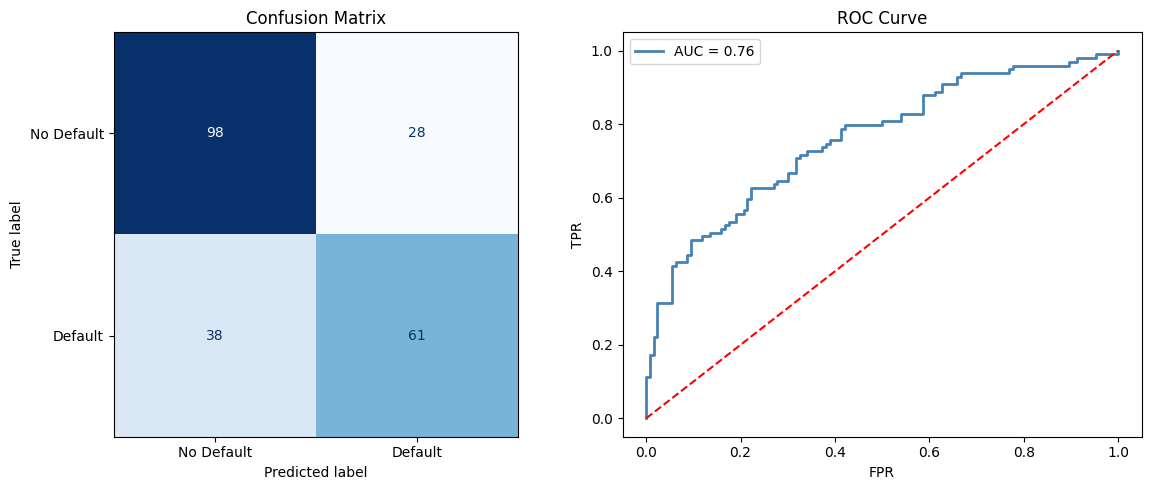

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_te_c, y_pred_c),
    display_labels=['No Default','Default']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_te_c, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label='AUC = ' + str(round(auc_val,3)))
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Comparison: NN vs Baseline Models

In [62]:
lr_base  = LinearRegression().fit(X_tr, y_tr_s)
y_lr     = lr_base.predict(X_te) * y_std + y_mean

print('Regression Comparison')
print(f'{"":15} {"Linear Reg":>12} {"Neural Net":>12}')
print(f'{"MAE":15} {mean_absolute_error(y_te, y_lr):>12,.0f} {mean_absolute_error(y_te, y_pred):>12,.0f}')
print(f'{"RMSE":15} {np.sqrt(mean_squared_error(y_te, y_lr)):>12,.0f} {np.sqrt(mean_squared_error(y_te, y_pred)):>12,.0f}')
print(f'{"R2":15} {r2_score(y_te, y_lr):>12.4f} {r2_score(y_te, y_pred):>12.4f}')

Regression Comparison
                  Linear Reg   Neural Net
MAE                   83,247       23,848
RMSE                 108,767       30,236
R2                   -0.8064       0.8604


In [63]:
log_base   = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42).fit(X_tr_c, y_tr_c)
y_log_prob = log_base.predict_proba(X_te_c)[:,1]
y_log_pred = log_base.predict(X_te_c)

print('Classification Comparison (Default class)')
print(f'{"":12} {"Logistic Reg":>14} {"Neural Net":>14}')
print(f'{"AUC":12} {roc_auc_score(y_te_c, y_log_prob):>14.4f} {auc_val:>14.4f}')
print(f'{"F1":12} {f1_score(y_te_c, y_log_pred):>14.4f} {f1_score(y_te_c, y_pred_c):>14.4f}')

Classification Comparison (Default class)
               Logistic Reg     Neural Net
AUC                  0.7331         0.7603
F1                   0.6495         0.6489


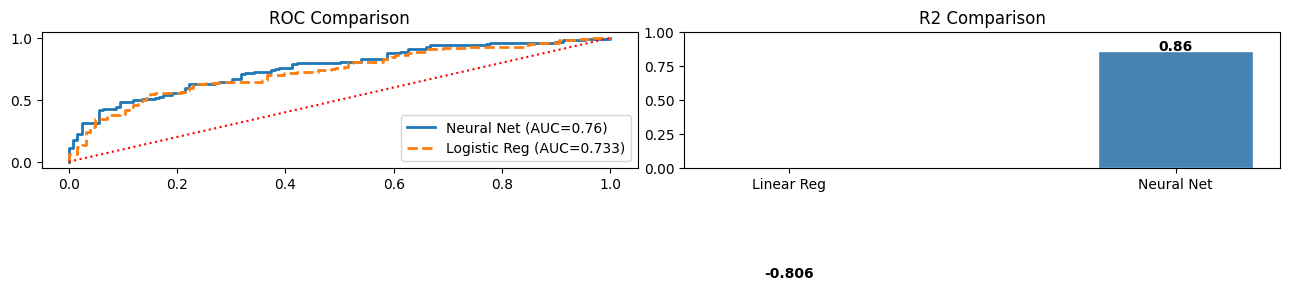

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_l, tpr_l, _ = roc_curve(y_te_c, y_log_prob)
axes[0].plot(fpr, tpr,   lw=2, label='Neural Net (AUC=' + str(round(auc_val,3)) + ')')
axes[0].plot(fpr_l, tpr_l, lw=2, linestyle='--', label='Logistic Reg (AUC=' + str(round(roc_auc_score(y_te_c, y_log_prob),3)) + ')')
axes[0].plot([0,1],[0,1],'r:'); axes[0].legend(); axes[0].set_title('ROC Comparison')

r2_nn = r2_score(y_te, y_pred)
r2_lr = r2_score(y_te, y_lr)
axes[1].bar(['Linear Reg','Neural Net'], [r2_lr, r2_nn],
            color=['darkorange','steelblue'], edgecolor='white', width=0.4)
for i, v in enumerate([r2_lr, r2_nn]):
    axes[1].text(i, v+0.005, str(round(v,3)), ha='center', fontweight='bold')
axes[1].set_ylim(0, 1); axes[1].set_title('R2 Comparison')
plt.tight_layout(); plt.show()